<a href="https://colab.research.google.com/github/shoham529-byte/1-repo/blob/main/mnist_fashion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [97]:
import zipfile
import os
import numpy as np
import struct

import matplotlib.pyplot as plt

import seaborn as sns

In [98]:
# Define the path to the zip file
zip_file_path = '/content/archive.zip'

# Define the directory to extract the contents to
extract_dir = '/content/extracted_data'

# Create the extraction directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"'{zip_file_path}' unzipped to '{extract_dir}'")

# List the contents of the extracted directory
print("Contents of the extracted directory:")
for root, dirs, files in os.walk(extract_dir):
    for name in files:
        print(os.path.join(root, name))
    for name in dirs:
        print(os.path.join(root, name))

'/content/archive.zip' unzipped to '/content/extracted_data'
Contents of the extracted directory:
/content/extracted_data/t10k-labels.idx1-ubyte
/content/extracted_data/train-labels.idx1-ubyte
/content/extracted_data/t10k-images.idx3-ubyte
/content/extracted_data/train-images.idx3-ubyte
/content/extracted_data/t10k-labels-idx1-ubyte
/content/extracted_data/t10k-images-idx3-ubyte
/content/extracted_data/train-labels-idx1-ubyte
/content/extracted_data/train-images-idx3-ubyte
/content/extracted_data/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte
/content/extracted_data/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte
/content/extracted_data/train-labels-idx1-ubyte/train-labels-idx1-ubyte
/content/extracted_data/train-images-idx3-ubyte/train-images-idx3-ubyte


In [99]:
def load_idx_images(filepath):
    """Loads IDX image files into a NumPy array."""
    with open(filepath, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack('>IIII', f.read(16))
        if magic != 2051:
            raise ValueError(f"Invalid magic number for image file: {magic}")
        images = np.frombuffer(f.read(), dtype=np.uint8).reshape(num_images, rows, cols)
    return images

def load_idx_labels(filepath):
    """Loads IDX label files into a NumPy array."""
    with open(filepath, 'rb') as f:
        magic, num_items = struct.unpack('>II', f.read(8))
        if magic != 2049:
            raise ValueError(f"Invalid magic number for label file: {magic}")
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

# Define the directory where files were extracted
extracted_data_dir = '/content/extracted_data'

# Load training images and labels
train_images = load_idx_images(os.path.join(extracted_data_dir, 'train-images.idx3-ubyte'))
train_labels = load_idx_labels(os.path.join(extracted_data_dir, 'train-labels.idx1-ubyte'))

# Load testing images and labels
test_images = load_idx_images(os.path.join(extracted_data_dir, 't10k-images.idx3-ubyte'))
test_labels = load_idx_labels(os.path.join(extracted_data_dir, 't10k-labels.idx1-ubyte'))

print(f"Train images shape: {train_images.shape}")
print(f"Train labels shape: {train_labels.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")

Train images shape: (60000, 28, 28)
Train labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


In [100]:
# 1. Normalize image pixel values
train_images_normalized = train_images.astype('float32') / 255.0
test_images_normalized = test_images.astype('float32') / 255.0

# 2. Reshape the image data
# Assuming images are 28x28
image_size = train_images_normalized.shape[1] * train_images_normalized.shape[2]
train_images_reshaped = train_images_normalized.reshape(train_images_normalized.shape[0], image_size)
test_images_reshaped = test_images_normalized.reshape(test_images_normalized.shape[0], image_size)

# 3. One-hot encode the labels
num_classes = 10  # MNIST has 10 classes (0-9)
train_labels_one_hot = to_categorical(train_labels, num_classes)
test_labels_one_hot = to_categorical(test_labels, num_classes)

print(f"Normalized train images shape: {train_images_normalized.shape}")
print(f"Normalized test images shape: {test_images_normalized.shape}")
print(f"Reshaped train images shape: {train_images_reshaped.shape}")
print(f"Reshaped test images shape: {test_images_reshaped.shape}")
print(f"One-hot encoded train labels shape: {train_labels_one_hot.shape}")
print(f"One-hot encoded test labels shape: {test_labels_one_hot.shape}")

Normalized train images shape: (60000, 28, 28)
Normalized test images shape: (10000, 28, 28)
Reshaped train images shape: (60000, 784)
Reshaped test images shape: (10000, 784)
One-hot encoded train labels shape: (60000, 10)
One-hot encoded test labels shape: (10000, 10)


In [101]:
# 1. Define the architecture of the neural network
input_size = train_images_reshaped.shape[1] # 784 for MNIST images
hidden_size_1 = 128 # Example: first hidden layer with 128 neurons
hidden_size_2 = 64  # Example: second hidden layer with 64 neurons
output_size = num_classes # 10 for MNIST digits (0-9)

print(f"Input Layer Size: {input_size}")
print(f"Hidden Layer 1 Size: {hidden_size_1}")
print(f"Hidden Layer 2 Size: {hidden_size_2}")
print(f"Output Layer Size: {output_size}")

# 2. Initialize weights and biases randomly
# Weights for input to first hidden layer
W1 = np.random.randn(input_size, hidden_size_1) * 0.01
b1 = np.zeros((1, hidden_size_1))

# Weights for first hidden layer to second hidden layer
W2 = np.random.randn(hidden_size_1, hidden_size_2) * 0.01
b2 = np.zeros((1, hidden_size_2))

# Weights for second hidden layer to output layer
W3 = np.random.randn(hidden_size_2, output_size) * 0.01
b3 = np.zeros((1, output_size))

print(f"Shape of W1: {W1.shape}")
print(f"Shape of b1: {b1.shape}")
print(f"Shape of W2: {W2.shape}")
print(f"Shape of b2: {b2.shape}")
print(f"Shape of W3: {W3.shape}")
print(f"Shape of b3: {b3.shape}")

Input Layer Size: 784
Hidden Layer 1 Size: 128
Hidden Layer 2 Size: 64
Output Layer Size: 10
Shape of W1: (784, 128)
Shape of b1: (1, 128)
Shape of W2: (128, 64)
Shape of b2: (1, 64)
Shape of W3: (64, 10)
Shape of b3: (1, 10)


In [102]:
def relu(Z):
    """Implements the Rectified Linear Unit (ReLU) activation function.

    Args:
        Z (np.ndarray): The input array.

    Returns:
        np.ndarray: The element-wise maximum of 0 and Z.
    """
    return np.maximum(0, Z)

def softmax(Z):
    """Implements the Softmax activation function for numerical stability.

    Args:
        Z (np.ndarray): The input array, typically the output of the last linear layer.

    Returns:
        np.ndarray: The softmax probabilities for each row.
    """
    # Subtract the maximum value for numerical stability to prevent overflow with exp()
    exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

print("ReLU and Softmax activation functions defined.")

ReLU and Softmax activation functions defined.


In [103]:
def cross_entropy_loss(predictions, true_labels):
    """Calculates the categorical cross-entropy loss.

    Args:
        predictions (np.ndarray): Predicted probabilities (softmax outputs).
        true_labels (np.ndarray): True labels (one-hot encoded).

    Returns:
        float: The average cross-entropy loss over the batch.
    """
    num_samples = predictions.shape[0]
    # Add a small epsilon to predictions to avoid log(0)
    epsilon = 1e-10
    predictions = np.clip(predictions, epsilon, 1. - epsilon)

    # Calculate cross-entropy loss
    loss = -np.sum(true_labels * np.log(predictions)) / num_samples
    return loss

print("Cross-entropy loss function defined.")

Cross-entropy loss function defined.


In [104]:
def forward_propagation(X, W1, b1, W2, b2, W3, b3):
    """Performs a forward pass through the neural network.

    Args:
        X (np.ndarray): Input data.
        W1 (np.ndarray): Weights for the first hidden layer.
        b1 (np.ndarray): Biases for the first hidden layer.
        W2 (np.ndarray): Weights for the second hidden layer.
        b2 (np.ndarray): Biases for the second hidden layer.
        W3 (np.ndarray): Weights for the output layer.
        b3 (np.ndarray): Biases for the output layer.

    Returns:
        tuple: A tuple containing Z1, A1, Z2, A2, Z3, A3.
    """
    # Layer 1
    Z1 = X.dot(W1) + b1
    A1 = relu(Z1)

    # Layer 2
    Z2 = A1.dot(W2) + b2
    A2 = relu(Z2)

    # Output Layer
    Z3 = A2.dot(W3) + b3
    A3 = softmax(Z3) # Predicted probabilities

    return Z1, A1, Z2, A2, Z3, A3

print("Forward propagation function defined.")

Forward propagation function defined.


In [105]:
def backward_propagation(X, Y, Z1, A1, Z2, A2, A3, W1, W2, W3):
    """Performs backward pass to calculate gradients.

    Args:
        X (np.ndarray): Input data.
        Y (np.ndarray): True labels (one-hot encoded).
        Z1 (np.ndarray): Linear combination of first hidden layer.
        A1 (np.ndarray): Activation of first hidden layer.
        Z2 (np.ndarray): Linear combination of second hidden layer.
        A2 (np.ndarray): Activation of second hidden layer.
        A3 (np.ndarray): Predicted probabilities (softmax output).
        W1 (np.ndarray): Weights for the first hidden layer.
        W2 (np.ndarray): Weights for the second hidden layer.
        W3 (np.ndarray): Weights for the output layer.

    Returns:
        tuple: Gradients dW1, db1, dW2, db2, dW3, db3.
    """
    m = X.shape[0] # Number of samples

    # Output Layer gradients
    dZ3 = A3 - Y
    dW3 = (A2.T).dot(dZ3) / m
    db3 = np.sum(dZ3, axis=0, keepdims=True) / m

    # Second Hidden Layer gradients
    dA2 = dZ3.dot(W3.T)
    dZ2 = dA2 * (Z2 > 0) # Derivative of ReLU
    dW2 = (A1.T).dot(dZ2) / m
    db2 = np.sum(dZ2, axis=0, keepdims=True) / m

    # First Hidden Layer gradients
    dA1 = dZ2.dot(W2.T)
    dZ1 = dA1 * (Z1 > 0) # Derivative of ReLU
    dW1 = (X.T).dot(dZ1) / m
    db1 = np.sum(dZ1, axis=0, keepdims=True) / m

    return dW1, db1, dW2, db2, dW3, db3

print("Backward propagation function defined.")

Backward propagation function defined.


In [106]:
def update_parameters(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, learning_rate):
    """Updates the network's weights and biases using gradient descent.

    Args:
        W1 (np.ndarray): Weights for the first hidden layer.
        b1 (np.ndarray): Biases for the first hidden layer.
        W2 (np.ndarray): Weights for the second hidden layer.
        b2 (np.ndarray): Biases for the second hidden layer.
        W3 (np.ndarray): Weights for the output layer.
        b3 (np.ndarray): Biases for the output layer.
        dW1 (np.ndarray): Gradients of weights for the first hidden layer.
        db1 (np.ndarray): Gradients of biases for the first hidden layer.
        dW2 (np.ndarray): Gradients of weights for the second hidden layer.
        db2 (np.ndarray): Gradients of biases for the second hidden layer.
        dW3 (np.ndarray): Gradients of weights for the output layer.
        db3 (np.ndarray): Gradients of biases for the output layer.
        learning_rate (float): The learning rate for gradient descent.

    Returns:
        tuple: Updated weights and biases (W1, b1, W2, b2, W3, b3).
    """
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W3 -= learning_rate * dW3
    b3 -= learning_rate * db3

    return W1, b1, W2, b2, W3, b3

print("Update parameters function defined.")

Update parameters function defined.


In [107]:
# 1. Define hyperparameters
learning_rate = 0.01
epochs = 30
batch_size = 64

# 2. Initialize empty lists to store loss and accuracy after each epoch
loss_history = []
test_accuracy_history = []

# Get the number of training samples
num_train_samples = train_images_reshaped.shape[0]

print("Starting neural network training...")

# 3. Implement a training loop
for epoch in range(epochs):
    # Shuffle training data at the beginning of each epoch
    permutation = np.random.permutation(num_train_samples)
    shuffled_train_images = train_images_reshaped[permutation]
    shuffled_train_labels = train_labels_one_hot[permutation]

    epoch_losses = []

    # Iterate through data in mini-batches
    for i in range(0, num_train_samples, batch_size):
        # Get current batch
        X_batch = shuffled_train_images[i:i + batch_size]
        Y_batch = shuffled_train_labels[i:i + batch_size]

        # 5a. Perform forward propagation
        Z1, A1, Z2, A2, Z3, A3 = forward_propagation(X_batch, W1, b1, W2, b2, W3, b3)

        # 5b. Calculate the loss for the current batch
        batch_loss = cross_entropy_loss(A3, Y_batch)
        epoch_losses.append(batch_loss)

        # 5d. Perform backward propagation
        dW1, db1, dW2, db2, dW3, db3 = backward_propagation(X_batch, Y_batch, Z1, A1, Z2, A2, A3, W1, W2, W3)

        # 5e. Update the weights and biases
        W1, b1, W2, b2, W3, b3 = update_parameters(W1, b1, W2, b2, W3, b3, dW1, db1, dW2, db2, dW3, db3, learning_rate)

    # 6. After each epoch, print the average loss
    avg_epoch_loss = np.mean(epoch_losses)
    loss_history.append(avg_epoch_loss)

    # Calculate test accuracy for the current epoch
    _, _, _, _, _, A3_test_epoch = forward_propagation(test_images_reshaped, W1, b1, W2, b2, W3, b3)
    predictions_epoch = np.argmax(A3_test_epoch, axis=1)
    epoch_test_accuracy = np.mean(predictions_epoch == true_labels_test) * 100
    test_accuracy_history.append(epoch_test_accuracy)

    print(f"Epoch {epoch + 1}/{epochs}, Average Loss: {avg_epoch_loss:.4f}, Test Accuracy: {epoch_test_accuracy:.2f}%")

print("Training complete!")

Starting neural network training...
Epoch 1/30, Average Loss: 2.3016, Test Accuracy: 11.35%
Epoch 2/30, Average Loss: 2.3001, Test Accuracy: 11.35%
Epoch 3/30, Average Loss: 2.2949, Test Accuracy: 12.70%
Epoch 4/30, Average Loss: 2.1384, Test Accuracy: 44.86%
Epoch 5/30, Average Loss: 1.1512, Test Accuracy: 75.94%
Epoch 6/30, Average Loss: 0.7008, Test Accuracy: 80.72%
Epoch 7/30, Average Loss: 0.6083, Test Accuracy: 83.18%
Epoch 8/30, Average Loss: 0.5533, Test Accuracy: 84.71%
Epoch 9/30, Average Loss: 0.5002, Test Accuracy: 86.61%
Epoch 10/30, Average Loss: 0.4409, Test Accuracy: 87.98%
Epoch 11/30, Average Loss: 0.3935, Test Accuracy: 89.11%
Epoch 12/30, Average Loss: 0.3606, Test Accuracy: 89.98%
Epoch 13/30, Average Loss: 0.3337, Test Accuracy: 90.64%
Epoch 14/30, Average Loss: 0.3117, Test Accuracy: 91.20%
Epoch 15/30, Average Loss: 0.2924, Test Accuracy: 91.92%
Epoch 16/30, Average Loss: 0.2741, Test Accuracy: 92.37%
Epoch 17/30, Average Loss: 0.2569, Test Accuracy: 92.83%
Epoc

In [108]:

accuracy_np = np.mean(predictions == true_labels_test) * 100
print(f"Test Accuracy (re-confirmed): {accuracy_np:.2f}%")


print(f"Test Loss: {test_loss:.4f}")


manual_cm = np.zeros((num_classes, num_classes), dtype=int)
for i in range(len(true_labels_test)):
    true_label = true_labels_test[i]
    predicted_label = predictions[i]
    manual_cm[true_label, predicted_label] += 1


precisions = []
recalls = []
f1_scores = []
per_class_accuracies = []

for i in range(num_classes):
    true_positives = manual_cm[i, i]
    false_positives = np.sum(manual_cm[:, i]) - true_positives
    false_negatives = np.sum(manual_cm[i, :]) - true_positives
    total_true_labels = np.sum(manual_cm[i, :])

    precision = true_positives / (true_positives + false_positives) if (true_positives + false_positives) > 0 else 0
    recall = true_positives / (true_positives + false_negatives) if (true_positives + false_negatives) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    class_accuracy = true_positives / total_true_labels if total_true_labels > 0 else 0

    precisions.append(precision)
    recalls.append(recall)
    f1_scores.append(f1_score)
    per_class_accuracies.append(class_accuracy)

macro_precision = np.mean(precisions)
macro_recall = np.mean(recalls)
macro_f1_score = np.mean(f1_scores)

print(f"Test Precision (Macro Avg): {macro_precision:.4f}")
print(f"Test Recall (Macro Avg): {macro_recall:.4f}")
print(f"Test F1-Score (Macro Avg): {macro_f1_score:.4f}")


Test Accuracy (re-confirmed): 95.91%
Test Loss: 0.4017
Test Precision (Macro Avg): 0.9588
Test Recall (Macro Avg): 0.9587
Test F1-Score (Macro Avg): 0.9587


Final Test Accuracy: 95.67%


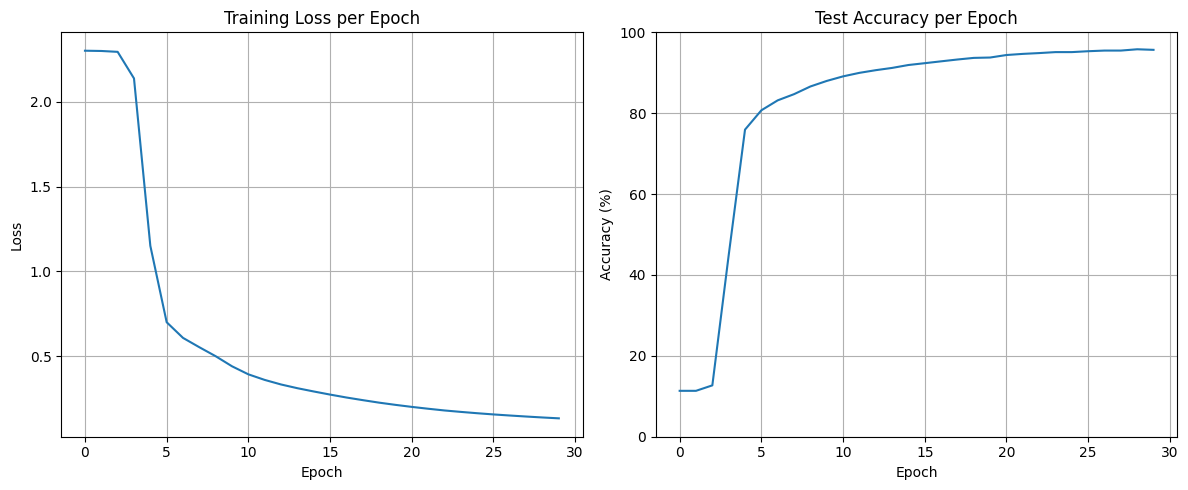

In [110]:

_, _, _, _, _,  A3_test = forward_propagation(test_images_reshaped, W1, b1, W2, b2, W3, b3)

predictions = np.argmax(A3_test, axis=1)

# Get true labels from one-hot encoded test_labels_one_hot
true_labels_test = np.argmax(test_labels_one_hot, axis=1)

# Calculate final accuracy
accuracy = np.mean(predictions == true_labels_test) * 100

print(f"Final Test Accuracy: {accuracy:.2f}%")

# 2. Plot Loss History and Accuracy History
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.title('Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(test_accuracy_history)
plt.title('Test Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.grid(True)

plt.tight_layout()
plt.show()